# General

For more informations, si the documentation *Documentary Strategy*.

# Import & Configs

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /home/jeremy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/jeremy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Data Upload

In [3]:
def get_cleaned_doc_df():
    documents = []

    with open("../data/processed/clean_documents.jsonl", "r") as f:
    
        for line in f:
            documents.append(json.loads(line))

    return pd.DataFrame(documents)

In [4]:
df = get_cleaned_doc_df()
df.head()

,pmid,title,abstract,year,text
0,42200192,Prediction of treatment failure in patients wi...,BACKGROUND: Predicting early treatment failure...,2026,Prediction of treatment failure in patients wi...
1,42200191,Imaging patterns of glioblastoma progression: ...,BACKGROUND: Glioblastoma is the most aggressiv...,2026,Imaging patterns of glioblastoma progression: ...
2,42198443,Antitumor Activity of Cannabinoids and Their I...,Background: Cannabinoids are studied as antica...,2026,Antitumor Activity of Cannabinoids and Their I...
3,42198270,Ultrasound-Enhanced Drug Delivery in Pediatric...,Pediatric brain tumors are highly prevalent an...,2026,Ultrasound-Enhanced Drug Delivery in Pediatric...
4,42195335,Artificial Intelligence-Based MRI Segmentation...,(1) Background: Differentiating between gliobl...,2026,Artificial Intelligence-Based MRI Segmentation...


# Sentence Splitting

In [5]:
example_text = df.iloc[0]["text"]

sentences = sent_tokenize(example_text)

sentences[:5]

['Prediction of treatment failure in patients with glioblastoma with perfusion MRI and molecular biomarkers.',
 'BACKGROUND: Predicting early treatment failure in glioblastoma remains challenging.',
 'Given the median survival of 13.5 months, better prognostic biomarkers are needed.',
 'This study aimed to identify predictors of early treatment failure and their association with overall survival (OS).',
 'METHODS: We performed a retrospective analysis of consecutive patients with newly diagnosed glioblastoma who underwent DSC- and DCE-MRI before surgery and radiochemotherapy.']

# Chunker

In [6]:
def create_chunks(
    text,
    chunk_size=500,
    overlap_sentences=1
):

    sentences = sent_tokenize(text)

    chunks = []

    current_chunk = []
    current_length = 0

    for sentence in sentences:

        sentence_length = len(sentence)

        if current_length + sentence_length > chunk_size:

            chunk_text = " ".join(current_chunk)
        
            if chunk_text.strip():
        
                chunks.append(chunk_text)
        
            overlap = current_chunk[-overlap_sentences:]
        
            current_chunk = overlap.copy()
        
            current_length = sum(
                len(s) for s in current_chunk
            )

        current_chunk.append(sentence)

        current_length += sentence_length

    if current_chunk:

        chunks.append(
            " ".join(current_chunk)
        )

    return chunks

# Chunks

## Exemple

In [7]:
sample_chunks = create_chunks(
    df.iloc[0]["text"]
)

In [8]:
len(sample_chunks)

6

In [9]:
print(sample_chunks[0])

Prediction of treatment failure in patients with glioblastoma with perfusion MRI and molecular biomarkers. BACKGROUND: Predicting early treatment failure in glioblastoma remains challenging. Given the median survival of 13.5 months, better prognostic biomarkers are needed. This study aimed to identify predictors of early treatment failure and their association with overall survival (OS).


In [10]:
print(sample_chunks[1])

This study aimed to identify predictors of early treatment failure and their association with overall survival (OS). METHODS: We performed a retrospective analysis of consecutive patients with newly diagnosed glioblastoma who underwent DSC- and DCE-MRI before surgery and radiochemotherapy. Treatment failure was defined as tumor progression per RANO 2.0 criteria within 6 months of surgery.


## Chunk all documents

In [11]:
all_chunks = []

In [12]:
for _, row in df.iterrows():

    chunks = create_chunks(
        row["text"]
    )

    for i, chunk in enumerate(chunks):

        all_chunks.append({

            "chunk_id": f'{row["pmid"]}_{i}',

            "pmid": row["pmid"],

            "chunk_index": i,

            "title": row["title"],

            "year": row["year"],

            "text": chunk
        })

In [13]:
chunk_df = pd.DataFrame(all_chunks)

## Exploration of chunks

In [14]:
chunk_df.head()

,chunk_id,pmid,chunk_index,title,year,text
0,42200192_0,42200192,0,Prediction of treatment failure in patients wi...,2026,Prediction of treatment failure in patients wi...
1,42200192_1,42200192,1,Prediction of treatment failure in patients wi...,2026,This study aimed to identify predictors of ear...
2,42200192_2,42200192,2,Prediction of treatment failure in patients wi...,2026,Treatment failure was defined as tumor progres...
3,42200192_3,42200192,3,Prediction of treatment failure in patients wi...,2026,RESULTS: Among 62 patients diagnosed between 0...
4,42200192_4,42200192,4,Prediction of treatment failure in patients wi...,2026,"A model, including age, perfusion metrics, and..."


In [15]:
len(chunk_df)

3260

In [16]:
chunk_df["chunk_length"] = (
    chunk_df["text"].apply(len)
)

In [17]:
chunk_df["chunk_length"].describe()

count    3260.000000
mean      420.603374
std        79.617874
min        84.000000
25%       376.000000
50%       425.000000
75%       470.000000
max      1031.000000
Name: chunk_length, dtype: float64

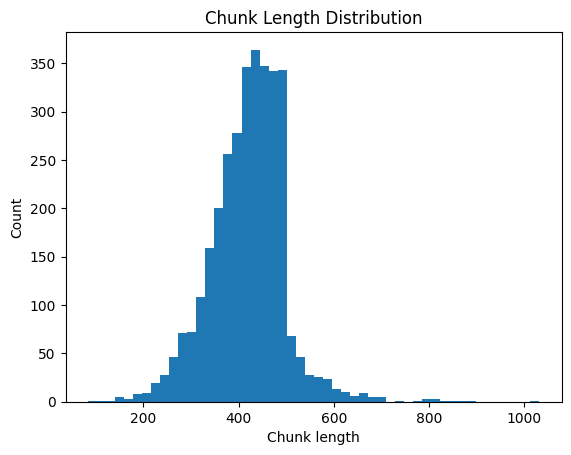

In [18]:
plt.hist(
    chunk_df["chunk_length"],
    bins=50
)

plt.xlabel("Chunk length")

plt.ylabel("Count")

plt.title("Chunk Length Distribution")

plt.show()

<Axes: ylabel='chunk_length'>

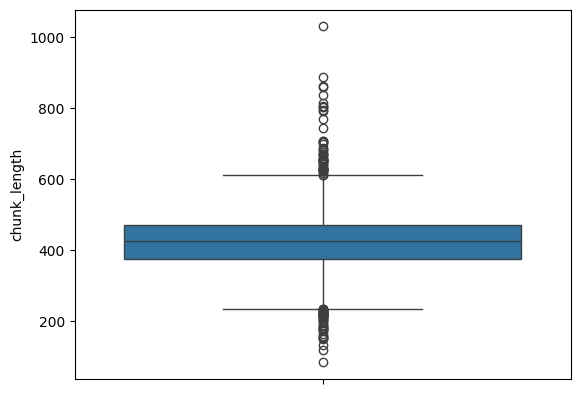

In [19]:
sns.boxplot(data=chunk_df["chunk_length"])

# Download Data

In [20]:
output_path = "../data/chunks/chunks.jsonl"

In [21]:
with open(output_path, "w") as f:

    for chunk in all_chunks:

        f.write(
            json.dumps(chunk) + "\n"
        )